### 필요 패키지 불러오기

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.metrics import accuracy_score, roc_curve, auc, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
import warnings
warnings.filterwarnings("ignore")


Using TensorFlow backend.


### 데이터 불러오기

In [2]:
# 온도 데이터 파일 불러오기
df_dc = pd.read_excel('온도_SOC.xlsx')
# 고도 데이터 파일 불러오기
df_ht = pd.read_excel('고도_SOC.xlsx')
# 배터리 데이터 파일 불러오기
df_bk = pd.read_excel('bank_SOC.xlsx')

### 데이터 전처리
- 독립변수와 종속변수 생성
- 학습데이터와 예측데이터(8:2의 비율)로 분리
- 결측치 제거

In [8]:
# 온도 데이터의 컬럼(필드명)들 저장
lst_cols_dc = df_dc.columns[1:]
# 미래 soc 만들기 위해 한칸씩 위로 올려서 데이터 만들기(3분의 데이터를 2분의 행으로 올리기)
df_dc_label = df_dc[lst_cols_dc].shift(-1)
# 미래 soc 들의 컬럼(필드명)들을 기존 데이터의 컬럼(필드명)들의 이름과 구별하기 위해 끝에 '_label'이라는 글자를 추가해주기
df_dc_label.columns = [i+'_label' for i in df_dc_label.columns]
# 과거 soc 데이터와 미래 soc 데이터를 하나의 데이터로 합치기
df_dc_total = pd.concat([df_dc,df_dc_label],axis=1)
# 결측치 데이터 제거
df_dc_total = df_dc_total.dropna()
# 학습을 위한 과거 데이터만 저장
X = df_dc_total[lst_cols_dc].fillna(0)
# 학습을 위한 미래 데이터만 저장
y = df_dc_total[df_dc_label.columns[0]].fillna(0)
# 학습데이터와 예측데이터를 만들기 위해서 8:2의 비율로 분리
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=.2)

### 모델링
- 모델의 파라미터 튜닝
- 모델의 학습
- 모델 예측
- 예측 결과 평가

In [66]:
# 모델의 파라미터 튜닝
# 머신러닝 모델은 여러개의 조정할 수 있는 값(파라미터)들이 존재하고, 이를 우리 데이터에 가장 알맞은 갑들로 설정할 경우,
# 더 좋은 성능을 만들어낼 수 있다.
# 따라서, 가장 좋은 값이 무엇인지 찾아내주는 기능을 한다.
def modelling(X_train, X_test, Y_train, Y_test, params, model):
    # 조합을 찾아내기 위한 파라미터들의 경우의 수와 모델 생성
    grid = GridSearchCV(model, params, cv=3, n_jobs = -1, scoring="neg_mean_squared_error", return_train_score = True)
    # 모델을 학습시킨다
    grid = grid.fit(X_train, Y_train)
    # 가장 좋은 파라미터들의 조합을 찾아내어 이를 저장한다
    model = grid.best_estimator_
    # 가장 좋은 파라미터들로 구성된 모델에 예측데이터를 투입하여 미래의 soc를 예측해낸다
    Y_test_pred = model.predict(X_test)
    # 가장 좋은 파라미터들이 무엇이였는지 출력해준다.
    print("best params : ", grid.best_params_)      
    return Y_test, Y_test_pred, model

# 모델의 성능 결과 평가
# 모델이 예측해낸 값과 실제 값의 차이를 비교하기 위해서 다양한 성능 지표를 계산한다.
# 각 지표들의 의미는 다음 블로그를 참고하길 바람
def evaluation(unnormalized_Y_test, unnormalized_Y_test_pred):
    # 실제값과 예측값을 집어넣어서, mae, mse, rmse, mape, mpe, r2 값들을 계산한다.
    Test_mae = MAE(unnormalized_Y_test, unnormalized_Y_test_pred)
    Test_mse = MSE(unnormalized_Y_test, unnormalized_Y_test_pred)
    Test_rmse = RMSE(unnormalized_Y_test, unnormalized_Y_test_pred)
    Test_mape = MAPE(unnormalized_Y_test, unnormalized_Y_test_pred)
    Test_mpe = MPE(unnormalized_Y_test, unnormalized_Y_test_pred)
    Test_r2 = r2_score(unnormalized_Y_test, unnormalized_Y_test_pred)
    # 각 계산한 값들을 하나의 리스트에 저장한다.
    lst_result = [Test_mae, Test_mse, Test_rmse, Test_mape, Test_mpe, Test_r2]
    # 각 계산한 값들을 출력한다.
    print('R2                  : %.4f' %(Test_r2))  
    print('MAE                 : %.2f' %(Test_mae))
    print('MSE                 : %.2f' %(Test_mse))
    print('RMSE                : %.2f' %(Test_rmse))
    print('MAPE                : %.2f' %(Test_mape))
    print('MPE                 : %.2f' %(Test_mpe))
    return lst_result

# 성능 평가 및 과적합 검증
# 각 성능 지표들의 계산 공식이다.
def MAE(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred)))
def MSE(y_true, y_pred):
    return np.mean(np.square((y_true - y_pred)))
def RMSE(y_true, y_pred):
    return np.sqrt(MSE(y_true, y_pred))
def MAPE(y_true, y_pred): 
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100
def MPE(y_true, y_pred): 
    return np.mean((y_true - y_pred) / y_true) * 100

# 테스트 데이터에 대한 예측결과와 실제결과 비교
def viz_result3(true, pred, lst_test_date):
    # 그래프의 크기를 설정한다.
    fig,ax = plt.subplots(figsize=(20,10))
    
    
    true_, pred_ = pd.Series(true), pd.Series(pred)
    # 실제값을 그래프로 시각화한다.
    ax1 = plt.plot(lst_test_date, true_, linewidth=2, dash_joinstyle='round', dash_capstyle='round')
    # 예측값을 그래프로 시각화한다.
    ax2 = plt.plot(lst_test_date, pred_, linewidth=2, dash_joinstyle='round', dash_capstyle='round')
    
    plt.legend(['true','pred'])
    plt.show()  

best params :  {'bootstrap': False, 'max_features': 4, 'n_estimators': 3}
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
test result

R2                  : 0.9841
MAE                 : 0.01
MSE                 : 0.00
RMSE                : 0.05
MAPE                : 5.75
MPE                 : 5.40
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 


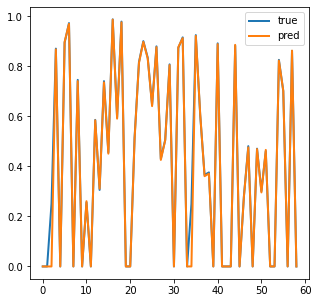

In [67]:
# 모델 구축
model_rf = RandomForestRegressor()
# 모델별 튜닝할 파라미터 선택
lst_params_rf = {"bootstrap":[False], "n_estimators":[3, 10], "max_features":[4, 8, 12, 16, 20]}
# 위의 modelling 함수를 이용하여 실제로 구동시킨다.
lst_y_test, lst_y_pred, model = modelling(X_train, X_test, Y_train, Y_test,
                                   lst_params_rf, model_rf)
# 예측 및 성능 평가
print('- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - ')

print('test result\n')
# 위의 evaluation 기능을 이용하여 성능 지표를 계산하게 한다.
lst_result = evaluation(lst_y_test, lst_y_pred)

print('- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - ')
# 위의 viz_result3 기능을 이용하여 예측값과 실제값을 시각화 한다.
lst_test_date = list(range(len(lst_y_pred)))
viz_result3(lst_y_test, lst_y_pred, lst_test_date)